In [1]:
import numpy as np
import matplotlib.pyplot as plt


── Gini Impurity ──────────────────────
All class 0:       0.0000
All class 1:       0.0000
50/50 split:       0.5000
4 class 1, 1 class 0: 0.3200


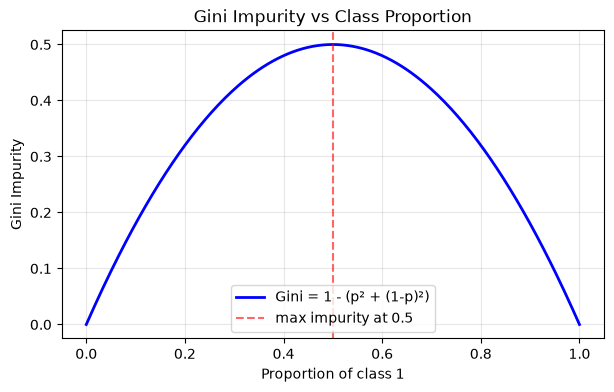

In [2]:
# Cell 2 — Version 1: understand Gini impurity manually
# Gini = 1 - Σ(pᵢ²)
# 0 = perfectly pure node, 0.5 = perfectly impure (50/50 split)

def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

# test cases
print("── Gini Impurity ──────────────────────")
print(f"All class 0:       {gini([0,0,0,0,0]):.4f}")     # perfect → 0
print(f"All class 1:       {gini([1,1,1,1,1]):.4f}")     # perfect → 0
print(f"50/50 split:       {gini([0,0,0,1,1,1]):.4f}")   # worst   → 0.5
print(f"4 class 1, 1 class 0: {gini([1,1,1,1,0]):.4f}")

# plot Gini vs proportion of class 1
p = np.linspace(0, 1, 300)
gini_curve = 1 - (p**2 + (1-p)**2)

plt.figure(figsize=(7, 4))
plt.plot(p, gini_curve, 'b-', linewidth=2, label='Gini = 1 - (p² + (1-p)²)')
plt.xlabel('Proportion of class 1'); plt.ylabel('Gini Impurity')
plt.title('Gini Impurity vs Class Proportion')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='max impurity at 0.5')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

── Entropy ────────────────────────────
All class 0:    -0.0000
All class 1:    -0.0000
50/50 split:    1.0000
4 vs 1:         0.7219


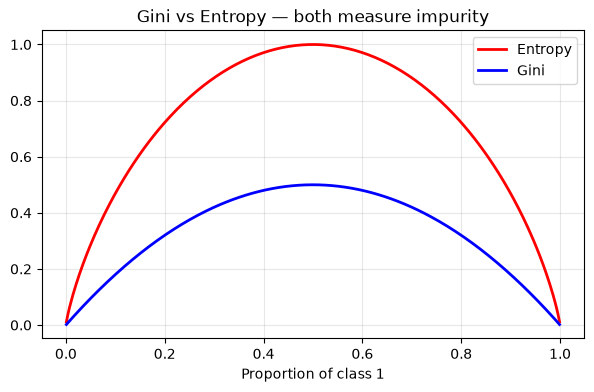

In [3]:
# Cell 3 — Version 2: Entropy (Information Gain)
# Entropy = -Σ(pᵢ * log₂(pᵢ))
# 0 = perfectly pure, 1 = perfectly impure (binary case)

def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

print("── Entropy ────────────────────────────")
print(f"All class 0:    {entropy([0,0,0,0,0]):.4f}")
print(f"All class 1:    {entropy([1,1,1,1,1]):.4f}")
print(f"50/50 split:    {entropy([0,0,0,1,1,1]):.4f}")   # max = 1.0 for binary
print(f"4 vs 1:         {entropy([1,1,1,1,0]):.4f}")

# plot Entropy vs proportion
p = np.linspace(0.001, 0.999, 300)
entropy_curve = -(p*np.log2(p) + (1-p)*np.log2(1-p))

plt.figure(figsize=(7, 4))
plt.plot(p, entropy_curve,         'r-', linewidth=2, label='Entropy')
plt.plot(p, 1-(p**2+(1-p)**2),     'b-', linewidth=2, label='Gini')
plt.xlabel('Proportion of class 1')
plt.title('Gini vs Entropy — both measure impurity')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [4]:
# Cell 4 — Version 3: Information Gain from a split
# IG = Entropy(parent) - weighted avg Entropy(children)
# Pick the split with HIGHEST information gain

def information_gain(parent, left, right):
    n = len(parent)
    weighted = (len(left)/n)*entropy(left) + (len(right)/n)*entropy(right)
    return entropy(parent) - weighted

# dataset: 10 students, pass/fail, split by study hours >= 5
y_all   = np.array([0,0,0,0,0,1,1,1,1,1])
y_left  = np.array([0,0,0,0,0])   # studied < 5 hrs → all fail
y_right = np.array([1,1,1,1,1])   # studied >= 5 hrs → all pass

ig = information_gain(y_all, y_left, y_right)
print(f"Parent entropy:       {entropy(y_all):.4f}")
print(f"Left child entropy:   {entropy(y_left):.4f}")
print(f"Right child entropy:  {entropy(y_right):.4f}")
print(f"Information Gain:     {ig:.4f}")
print("IG = 1.0 → perfect split ✅")

# messy split
y_left2  = np.array([0,0,1,0,0])
y_right2 = np.array([1,1,0,1,1])
ig2 = information_gain(y_all, y_left2, y_right2)
print(f"\nMessy split IG: {ig2:.4f}")

Parent entropy:       1.0000
Left child entropy:   -0.0000
Right child entropy:  -0.0000
Information Gain:     1.0000
IG = 1.0 → perfect split ✅

Messy split IG: 0.2781


Threshold=1.5  IG=0.1080
Threshold=2.0  IG=0.1080
Threshold=2.5  IG=0.2365
Threshold=3.0  IG=0.2365
Threshold=3.5  IG=0.3958
Threshold=4.0  IG=0.3958
Threshold=4.5  IG=0.6100
Threshold=5.0  IG=0.6100
Threshold=5.5  IG=1.0000
Threshold=6.0  IG=1.0000
Threshold=6.5  IG=0.6100
Threshold=7.0  IG=0.6100
Threshold=7.5  IG=0.3958
Threshold=8.0  IG=0.3958
Threshold=8.5  IG=0.2365
Threshold=9.0  IG=0.2365
Threshold=9.5  IG=0.1080

Best split threshold: X < 5.5 | IG = 1.0000


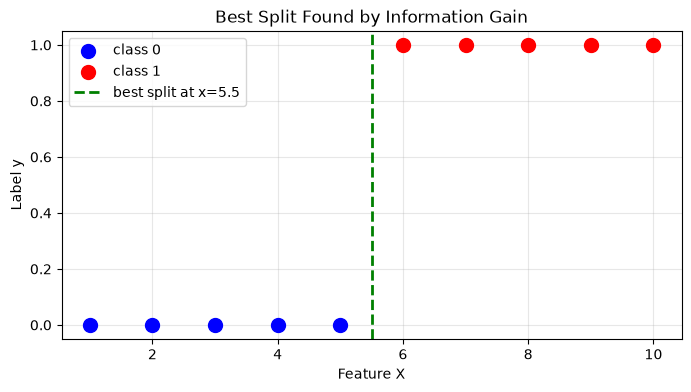

In [5]:
# Cell 5 — Version 4: find best split threshold on 1D data
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y = np.array([0,0,0,0,0,1,1,1,1,1])

best_threshold, best_ig = None, -1

for threshold in np.arange(1.5, 10, 0.5):
    left_mask  = X < threshold
    right_mask = X >= threshold
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        continue
    ig = information_gain(y, y[left_mask], y[right_mask])
    print(f"Threshold={threshold:.1f}  IG={ig:.4f}")
    if ig > best_ig:
        best_ig, best_threshold = ig, threshold

print(f"\nBest split threshold: X < {best_threshold} | IG = {best_ig:.4f}")

plt.figure(figsize=(8, 4))
plt.scatter(X[y==0], y[y==0], color='blue', s=100, label='class 0', zorder=5)
plt.scatter(X[y==1], y[y==1], color='red',  s=100, label='class 1', zorder=5)
plt.axvline(best_threshold, color='green', linestyle='--', linewidth=2,
            label=f'best split at x={best_threshold}')
plt.xlabel('Feature X'); plt.ylabel('Label y')
plt.title('Best Split Found by Information Gain')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()